In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
theme_set(theme_light())

In [3]:
library(tidymodels)

── Attaching packages ────────────────────────────────────── tidymodels 1.4.1 ──

✔ broom        1.0.11     ✔ rsample      1.3.1 
✔ dials        1.4.2      ✔ tailor       0.1.0 
✔ infer        1.1.0      ✔ tune         2.0.1 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.4.1      ✔ workflowsets 1.1.1 
✔ recipes      1.3.1      ✔ yardstick    1.3.2 

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()



In [4]:
set.seed(20260119)

In [5]:
files <- list.files(path="analysis/features_normalized/ACDC/", pattern="*.csv$", full.names = T)
length(files)

[1] 100

In [6]:
data <- read_csv(files)

Rows: 110618 Columns: 915
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (4): file, image_path, segmentation_path, extraction_ID
dbl (866): ID, original_firstorder_10Percentile, original_firstorder_90Perce...
lgl  (45): lbp-2D_firstorder_Entropy, lbp-2D_firstorder_Maximum, lbp-2D_firs...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [7]:
metadata <- read_tsv("data/ACDC_dataset/group.tsv", col_names = c("patient", "group")) |>
	mutate(set = c(rep(c(rep("train", 12), rep("val", 4), rep("test", 4)),5)))

Rows: 100 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): patient, group

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
ranks <- read_tsv("figures/supp_tab1.tsv")

Rows: 910 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): Feature_name
dbl (6): mean_mae, sd, rank, mean_within_mae, within_sd, within_rank

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [9]:
subsampleTo <- function(n, to=12){
	round(seq(0,n,length.out=to))
}

In [ ]:
data_subsampled <- data |>
	select(-c(image_path, segmentation_path, extraction_ID)) |>
	filter(ID %in% subsampleTo(max(ID),12), .by=file) |>
	mutate(ID = str_glue("f{row_number()}"), .by=file) |>
	mutate(
		file=str_remove(file, ".csv"),
	) |>
	separate(file, into=c("patient","noise","seed"), sep="_") |>
	left_join(metadata, by="patient") |>
	# Remove noisy curves from the test set
	filter(set != "test" | noise == "0.000") |>
	mutate(group = as.factor(group))

In [12]:
complete_features <- data_subsampled |>
	pivot_longer(names_to="feature", contains("_")) |>
	count(feature, nac=is.na(value)) |>
	pivot_wider(names_from=nac, values_from=n, values_fill=0) |>
	filter(`TRUE`==0) |>
	pull(feature)

In [13]:
data_nested <- data_subsampled |>
	pivot_longer(names_to="feature", contains("_")) |>
	filter(feature %in% complete_features) |>
	#head(2000000) |>
	nest_by(feature)

In [14]:
data_nested <- data_nested |> #head(200) |>
	mutate(data = list(pivot_wider(data, names_from=ID, values_from=value))) |>
	mutate(
		train = list(filter(data, set=="train")),
		val = list(filter(data, set=="val")),
		test = list(filter(data, set=="test")),
	) |>
	select(-data)

In [15]:
decision_tree_fit <- workflow() |>
	add_model(decision_tree(mode="classification")) |>
	add_variables(outcomes = group, predictors = f1:f12)

In [16]:
data_acc <- data_nested |>
	#head(100) |>
	mutate(
		my_fit = list(fit(decision_tree_fit, train)),
		val = list(augment(my_fit, val)),
		test = list(augment(my_fit, test)),
		val_acc = accuracy(val, group, .pred_class) |> pull(.estimate),
		test_acc = accuracy(test, group, .pred_class) |> pull(.estimate)
	) |>
	select(feature, val_acc, test_acc)

In [17]:
data_acc <- data_acc |>
	ungroup() |>
	left_join(ranks |> select(feature=Feature_name, rank), by="feature")

In [18]:
min_performance = 0.33

`geom_smooth()` using formula = 'y ~ x'


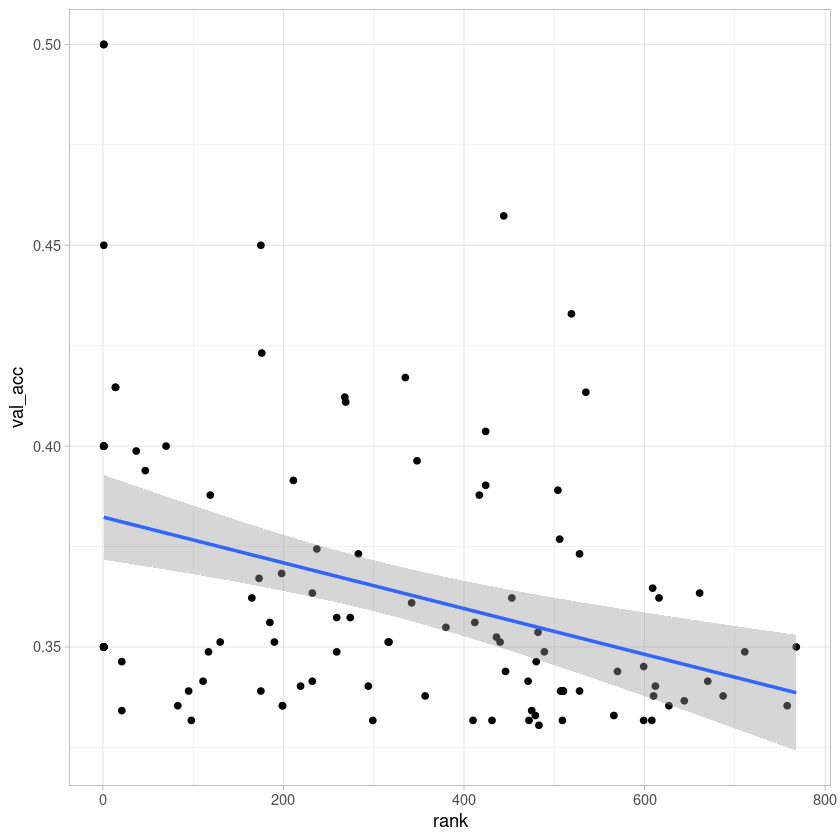

In [19]:
data_acc |>
	filter(val_acc >= min_performance) |>
	ggplot(aes(x=rank, y=val_acc)) + geom_point() + geom_smooth(method="lm")

In [20]:
data_acc |>
	filter(val_acc>=min_performance) |>
	arrange(rank) |>
	mutate(
		rank_notie = row_number(),
		range = case_when(
		rank_notie <= 15 ~ "top",
		length(rank_notie) - rank_notie <= 15 ~ "bottom",
		.default = "middle",
	)) |>
	summarize(median(val_acc), .by=range)

range,median(val_acc)
<chr>,<dbl>
top,0.4000000
middle,0.3500000
bottom,0.3408537


In [21]:
data_acc |>
	filter(val_acc>=min_performance) |>
	summarize(cor = cor(rank, val_acc, method="spearman"))

cor
<dbl>
-0.384148
